### Import Libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from operator import itemgetter

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
train=pd.read_csv('used_car_train_20200313.csv',sep=' ')

In [4]:
test=pd.read_csv('used_car_testA_20200313.csv',sep=' ')

In [5]:
print(train.shape)
print(test.shape)

(150000, 31)
(50000, 30)


In [6]:
train.head()

,SaleID,name,regDate,model,brand,bodyType,fuelType,gearbox,power,kilometer,...,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,v_13,v_14
0,0,736,20040402,30.0,6,1.0,0.0,0.0,60,12.5,...,0.235676,0.101988,0.129549,0.022816,0.097462,-2.881803,2.804097,-2.420821,0.795292,0.914762
1,1,2262,20030301,40.0,1,2.0,0.0,0.0,0,15.0,...,0.264777,0.121004,0.135731,0.026597,0.020582,-4.900482,2.096338,-1.030483,-1.722674,0.245522
2,2,14874,20040403,115.0,15,1.0,0.0,0.0,163,12.5,...,0.251410,0.114912,0.165147,0.062173,0.027075,-4.846749,1.803559,1.565330,-0.832687,-0.229963
3,3,71865,19960908,109.0,10,0.0,0.0,1.0,193,15.0,...,0.274293,0.110300,0.121964,0.033395,0.000000,-4.509599,1.285940,-0.501868,-2.438353,-0.478699
4,4,111080,20120103,110.0,5,1.0,0.0,0.0,68,5.0,...,0.228036,0.073205,0.091880,0.078819,0.121534,-1.896240,0.910783,0.931110,2.834518,1.923482


In [7]:
train.columns

Index(['SaleID', 'name', 'regDate', 'model', 'brand', 'bodyType', 'fuelType',
       'gearbox', 'power', 'kilometer', 'notRepairedDamage', 'regionCode',
       'seller', 'offerType', 'creatDate', 'price', 'v_0', 'v_1', 'v_2', 'v_3',
       'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12',
       'v_13', 'v_14'],
      dtype='object')

In [8]:
test.columns

Index(['SaleID', 'name', 'regDate', 'model', 'brand', 'bodyType', 'fuelType',
       'gearbox', 'power', 'kilometer', 'notRepairedDamage', 'regionCode',
       'seller', 'offerType', 'creatDate', 'v_0', 'v_1', 'v_2', 'v_3', 'v_4',
       'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12', 'v_13',
       'v_14'],
      dtype='object')

---

### Delete outliers

- Function: Detects and removes outliers from a specified column `col_name` using boxplot (IQR) rules, and outputs a new dataset after outlier removal.

- Input:

`data`: A DataFrame dataset (Pandas).

`col_name`: The name (string) of the column to be checked for outliers.

`scale`: The scaling factor (commonly 1.5 or 3; defaults to 3 here). For IQR (Interquartile Range) rules: Lower bound = Q1 − scale * IQR; Upper bound = Q3 + scale * IQR.

- Output: `data_n`, the DataFrame after outlier removal in this column.

- outliers_proc:
Used for cleaning outliers; the default cleaning method is `box_plot(scale=3)`.

:param data: Receives pandas data format

:param col_name: Pandas column name

:param scale: Scale

:return:

- box_plot_outliers:
Remove outliers using boxplots

:param data_ser: Receives pandas.Series data format

:param box_scale: Boxplot scale

:return:

In [9]:
def outliers_proc(data,col_name,scale=3):#The scale setting controls the leniency of outlier detection (the larger the scale, the more lenient the outlier, and the more outliers are retained)
    def box_plot_outliers(data_serie,box_scale):
        iqr=box_scale*(data_serie.quantile(0.75)-data_serie.quantile(0.25))
        val_low=data_serie.quantile(0.25)-iqr
        val_up=data_serie.quantile(0.75)+iqr
        #two boolean masks--True for outliers
        rule_low=(data_serie<val_low)
        rule_up=(data_serie>val_up)
        return(rule_low,rule_up),(val_low,val_up)
    data_n=data.copy()
    data_series = data_n[col_name].dropna()
    rule,value=box_plot_outliers(data_series,box_scale=scale)
    index=np.arange(data_series.shape[0])[rule[0]| rule[1]]
    print("Delete number is: {}".format(len(index)))#Logging the number of deleted outliers
    data_n=data_n.drop(index)#follow lables in data_series
    data_n.reset_index(drop=True,inplace=True)#reset index after deletion
    print("Now row count is: {}".format(data_n.shape[0]))
    index_low = np.arange(data_series.shape[0])[rule[0]]
    outliers = data_series.iloc[index_low]
    print("Description of data less than the lower bound is:")
    print(pd.Series(outliers).describe())
    index_up = np.arange(data_series.shape[0])[rule[1]]
    outliers = data_series.iloc[index_up]
    print("Description of data larger than the upper bound is:")
    print(pd.Series(outliers).describe())
    #Plot before and after box plots
    f, ax = plt.subplots(1, 2, figsize=(12, 9))
    sns.boxplot(y=data[col_name], data=data, palette="Set1", ax=ax[0])
    sns.boxplot(y=data_n[col_name], data=data_n, palette="Set1", ax=ax[1])
    return data_n

Here we delete some outliers in trainning set-power

Delete number is: 10159
Now row count is: 139841
Description of data less than the lower bound is:
count    10159.000000
mean         2.436165
std          1.267770
min          0.500000
25%          1.000000
50%          3.000000
75%          4.000000
max          4.000000
Name: kilometer, dtype: float64
Description of data larger than the upper bound is:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: kilometer, dtype: float64


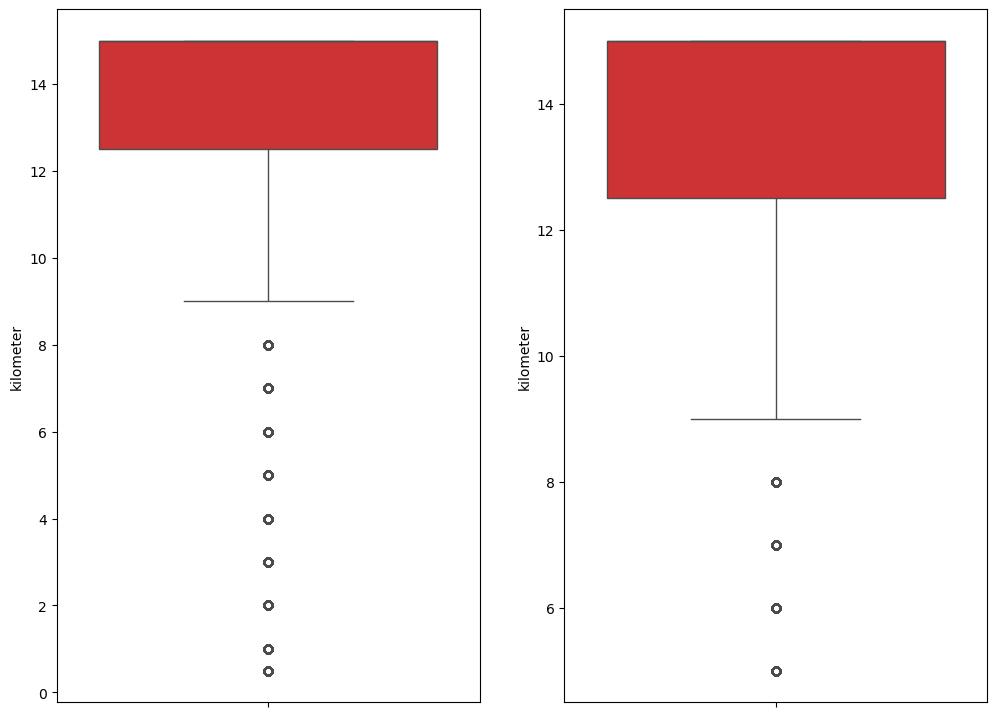

In [10]:
train=outliers_proc(train,'kilometer',scale=3)

Delete number is: 809
Now row count is: 139032
Description of data less than the lower bound is:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: power, dtype: float64
Description of data larger than the upper bound is:
count      809.000000
mean       814.452410
std       1756.573587
min        376.000000
25%        400.000000
50%        435.000000
75%        514.000000
max      19312.000000
Name: power, dtype: float64


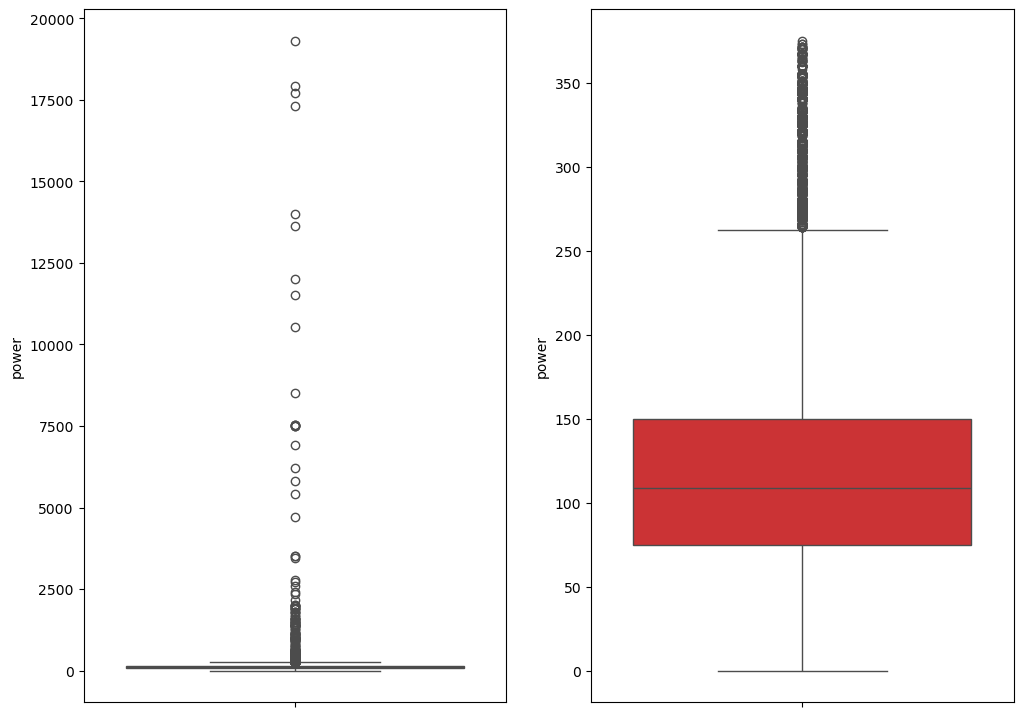

In [11]:
train = outliers_proc(train,'power',scale=3)

### Feature Construction

In [12]:
train['train']=1
test['test']=0
data = pd.concat([train,test],ignore_index=True,sort=False)

Normally, price is inversely proportional to usage time

In [13]:
#The data contains a time error format, so we need errors='coerce'
data['used_time'] = (pd.to_datetime(data['creatDate'], format='%Y%m%d', errors='coerce') - pd.to_datetime(data['regDate'], format='%Y%m%d', errors='coerce')).dt.days

In [14]:
data['used_time'].isnull().sum()

np.int64(14180)

The amount of missing data removed is too large compared to the total sample size. So I didn't delete it.

Get city info from postcode

In [15]:
data['city']=data['regionCode'].apply(lambda x: str(x)[:-3])

groupby brand features

In [16]:
train_gb1 = train.groupby("brand")
all_info = {}
for kind, kind_data in train_gb1:
    info = {}
    kind_data = kind_data[kind_data['price'] > 0]
    info['brand_amount'] = len(kind_data)
    info['brand_price_max'] = kind_data.price.max()
    info['brand_price_median'] = kind_data.price.median()
    info['brand_price_min'] = kind_data.price.min()
    info['brand_price_sum'] = kind_data.price.sum()
    info['brand_price_std'] = kind_data.price.std()
    info['brand_price_average'] = round(kind_data.price.sum() / (len(kind_data) + 1), 2)
    all_info[kind] = info
brand_fe = pd.DataFrame(all_info).T.reset_index().rename(columns={"index": "brand"})
data = data.merge(brand_fe, how='left', on='brand')

In [17]:
train_gb2 = train.groupby("model")
all_info = {}
for kind, kind_data in train_gb2:
    info = {}
    kind_data = kind_data[kind_data['price'] > 0]
    info['model_price_max'] = kind_data.price.max()
    info['model_price_median'] = kind_data.price.median()
    info['model_price_min'] = kind_data.price.min()
    info['model_price_sum'] = kind_data.price.sum()
    info['model_price_std'] = kind_data.price.std()
    all_info[kind] = info
model_fe = pd.DataFrame(all_info).T.reset_index().rename(columns={"index": "model"})
data = data.merge(model_fe, how='left', on='model')

In [18]:
bin = [i*10 for i in range(31)]
data['power_bin'] = pd.cut(data['power'], bin, labels=False)
data[['power_bin', 'power']].head()

,power_bin,power
0,5.0,60
1,NaN,0
2,16.0,163
3,19.0,193
4,6.0,68


In [19]:
data=data.drop(['creatDate','regDate','regionCode'],axis=1)

In [20]:
print(data.shape)

(189032, 45)


In [21]:
data.columns

Index(['SaleID', 'name', 'model', 'brand', 'bodyType', 'fuelType', 'gearbox',
       'power', 'kilometer', 'notRepairedDamage', 'seller', 'offerType',
       'price', 'v_0', 'v_1', 'v_2', 'v_3', 'v_4', 'v_5', 'v_6', 'v_7', 'v_8',
       'v_9', 'v_10', 'v_11', 'v_12', 'v_13', 'v_14', 'train', 'test',
       'used_time', 'city', 'brand_amount', 'brand_price_max',
       'brand_price_median', 'brand_price_min', 'brand_price_sum',
       'brand_price_std', 'brand_price_average', 'model_price_max',
       'model_price_median', 'model_price_min', 'model_price_sum',
       'model_price_std', 'power_bin'],
      dtype='object')

In [22]:
data.to_csv('data_for_tree.csv',index=0)